In [1]:
from alerce.core import Alerce
from astropy.table import vstack, Table
import json
import matplotlib.pyplot as plt
import pyvo as vo
import requests
import sqlalchemy as sa
import sys
import numpy as np
from astropy.coordinates import SkyCoord
import george
import scipy.optimize as op
import emcee
from matplotlib.backends.backend_pdf import PdfPages
import george
import scipy.optimize as op
import emcee

In [2]:
import utils

In [13]:
curve_type = "II"

In [14]:
#open light curves
with open(f"../Data/{curve_type}.json", 'r') as f:
    light_curves = json.load(f)

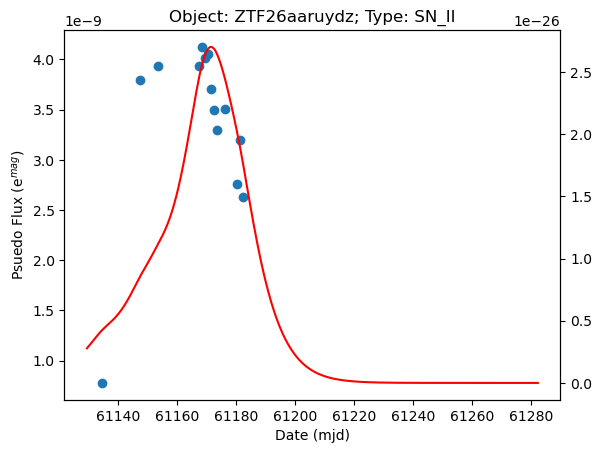

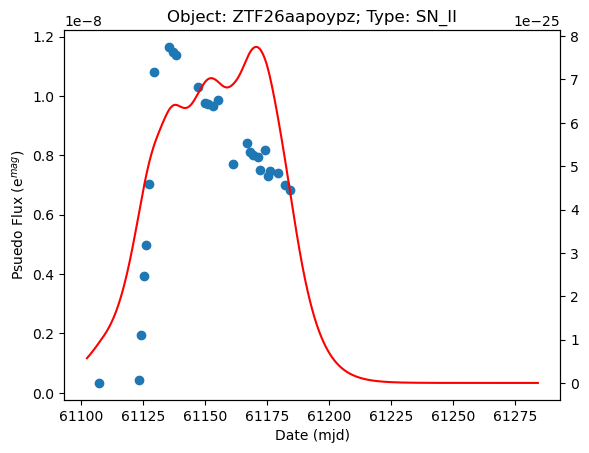

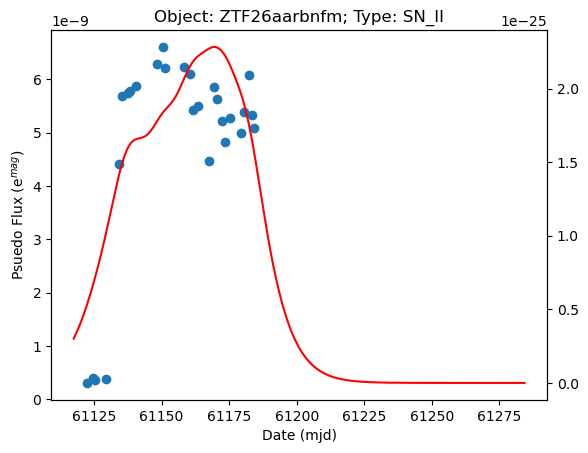

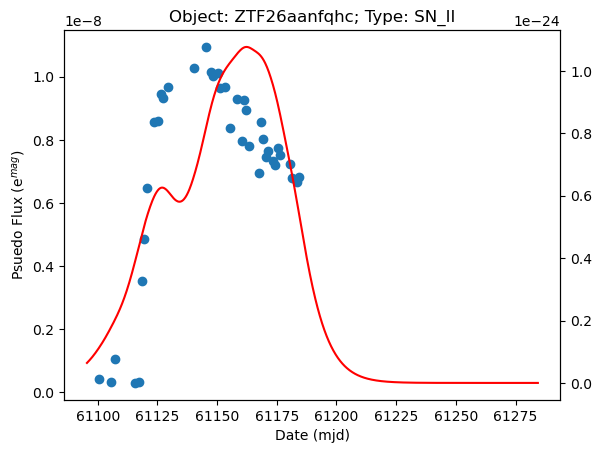

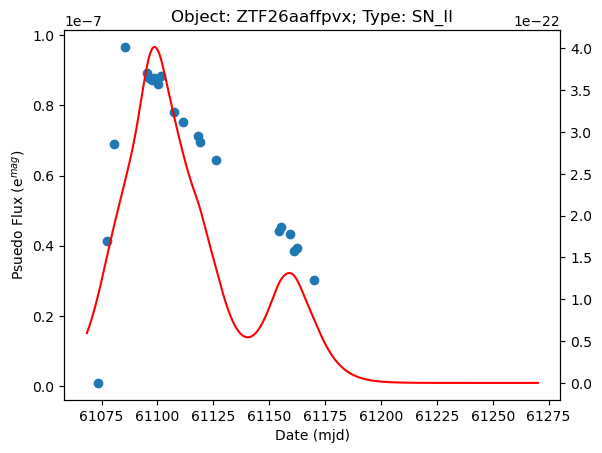

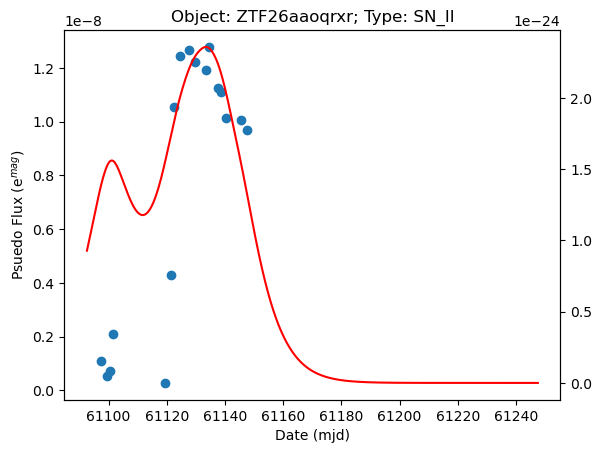

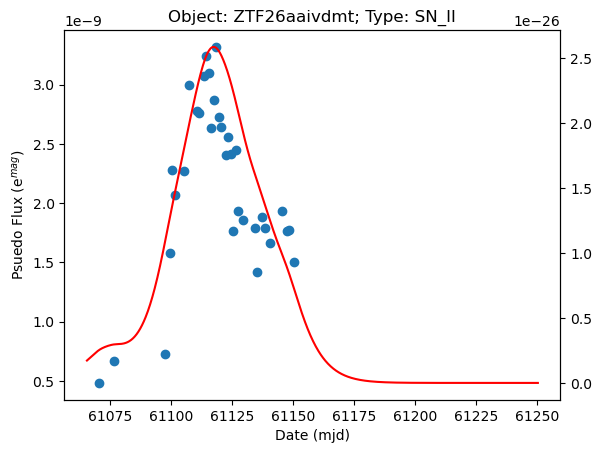

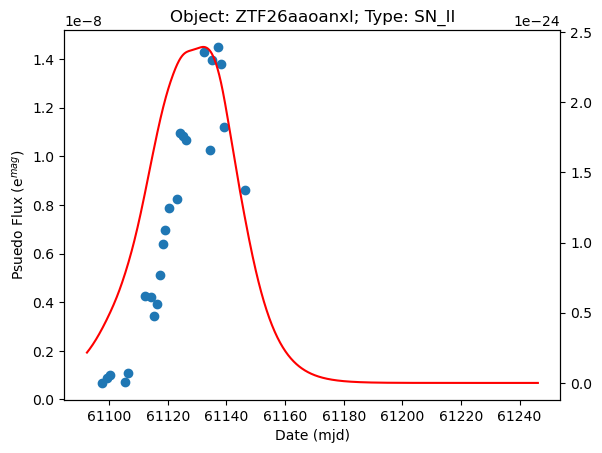

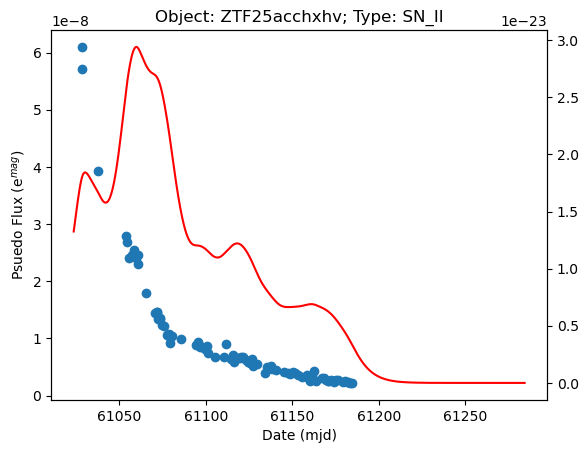

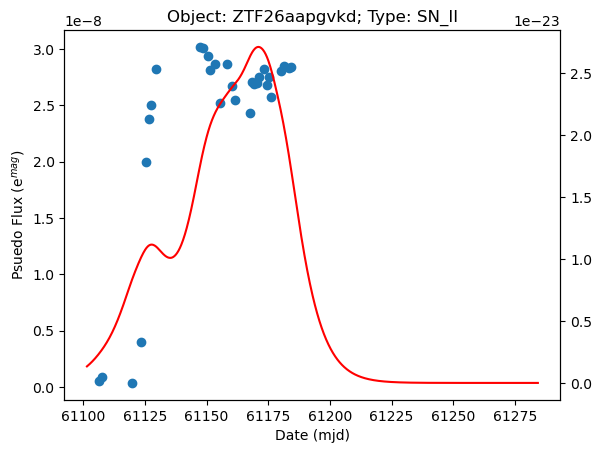

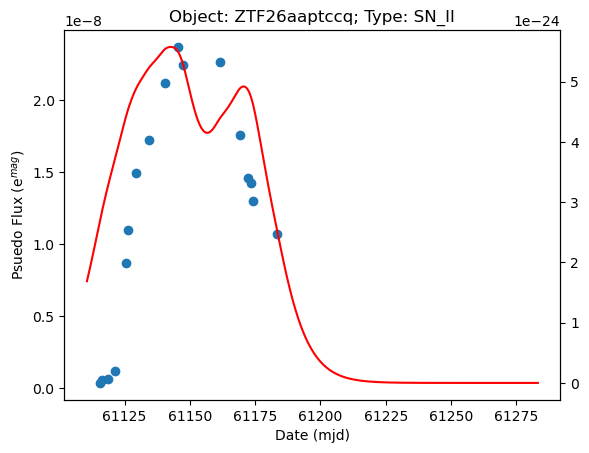

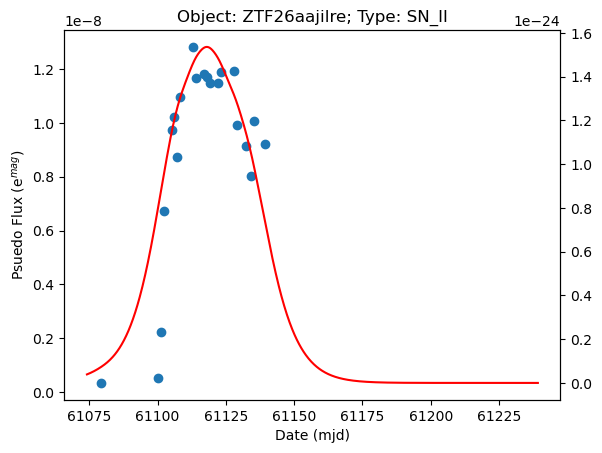

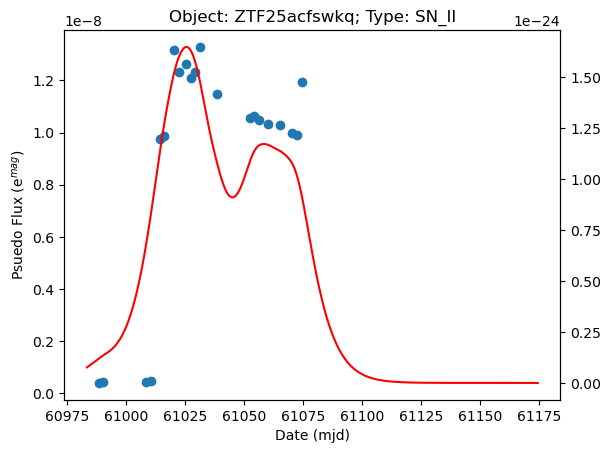

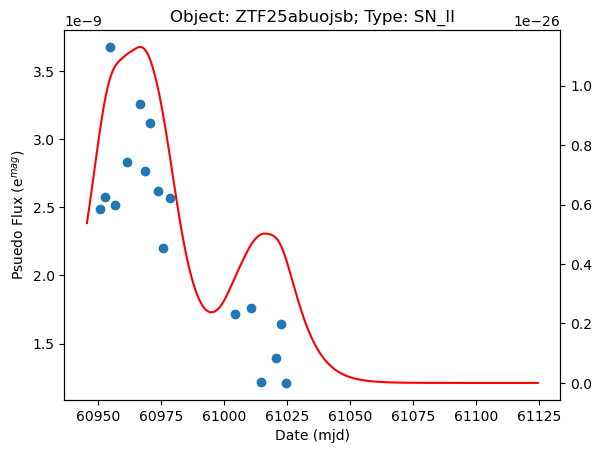

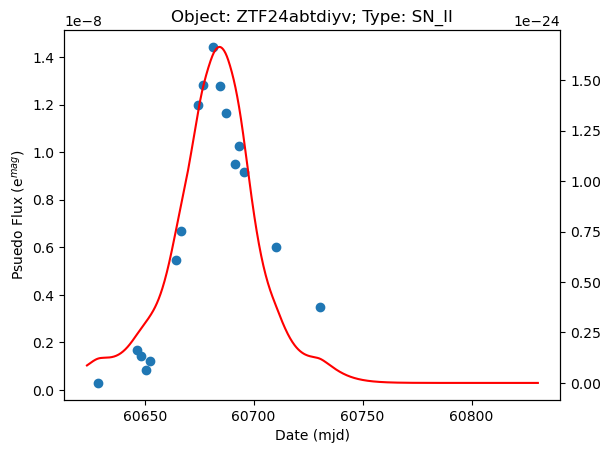

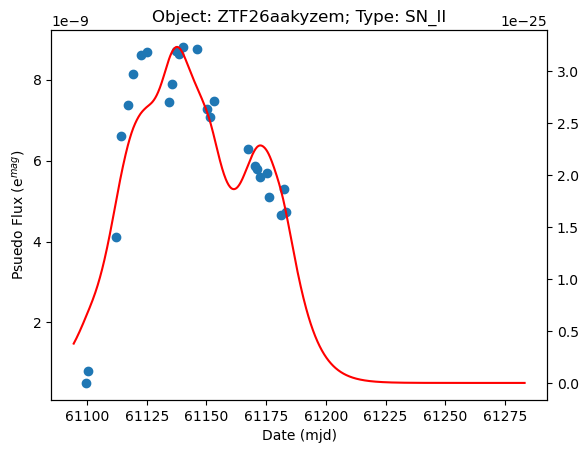

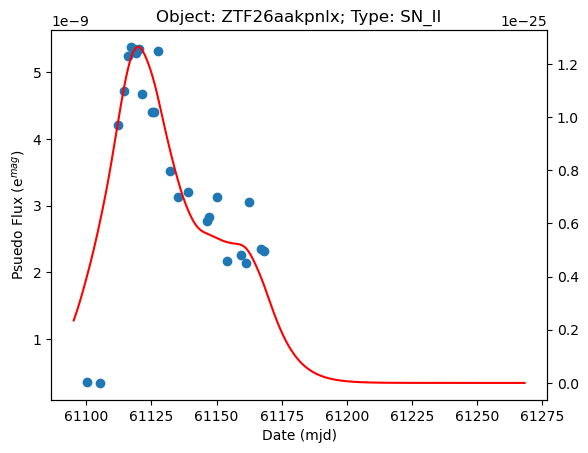

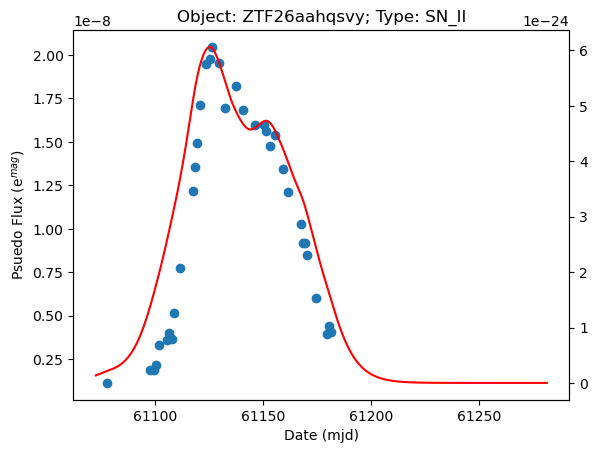

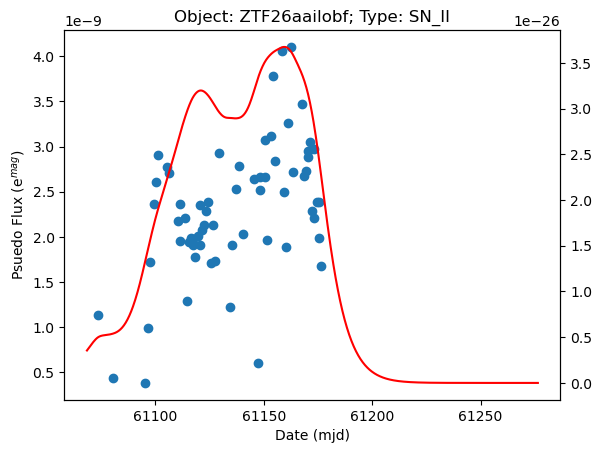

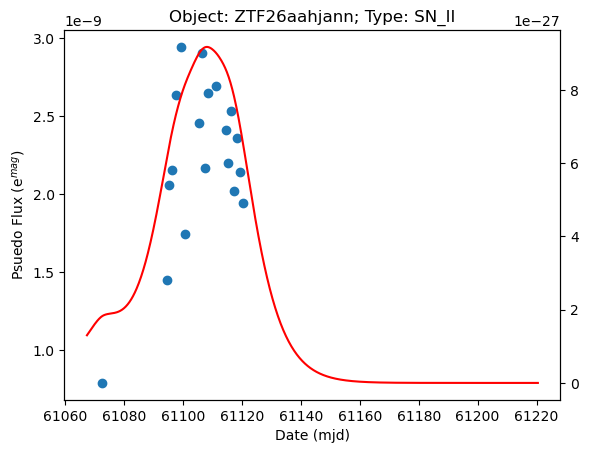

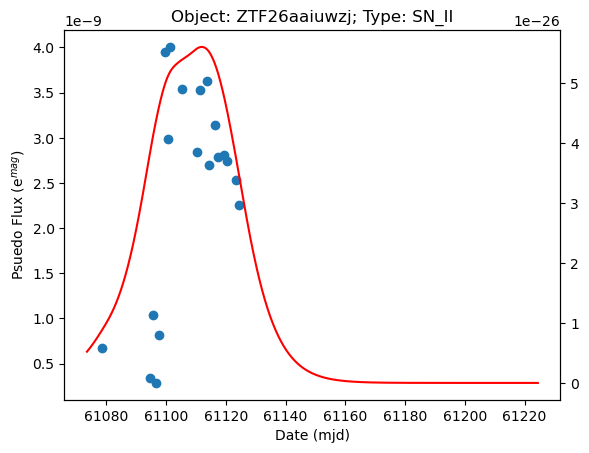

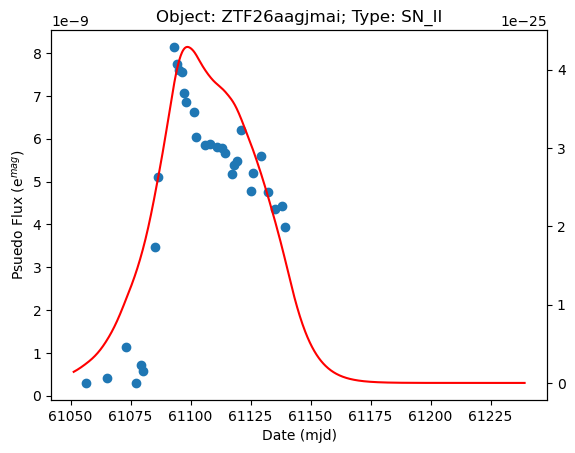

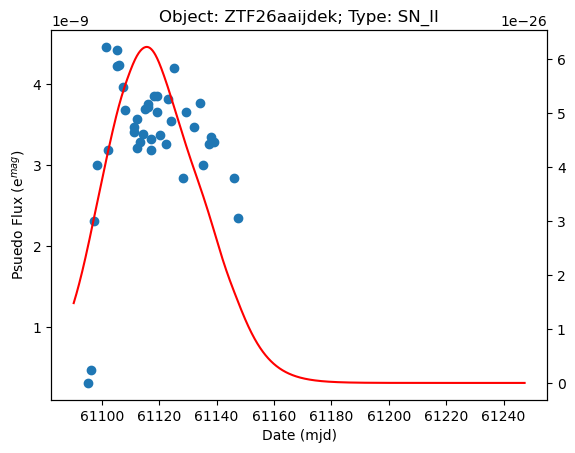

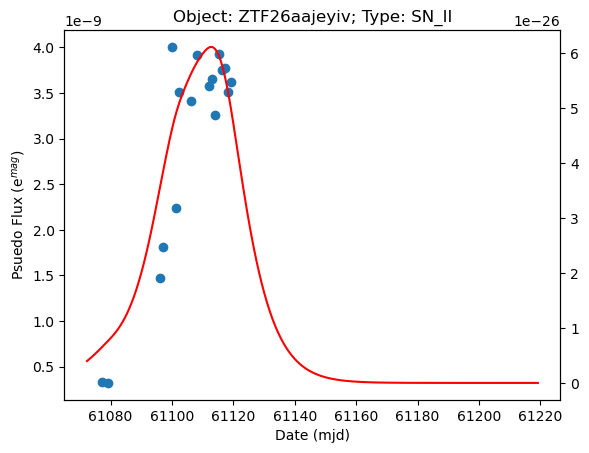

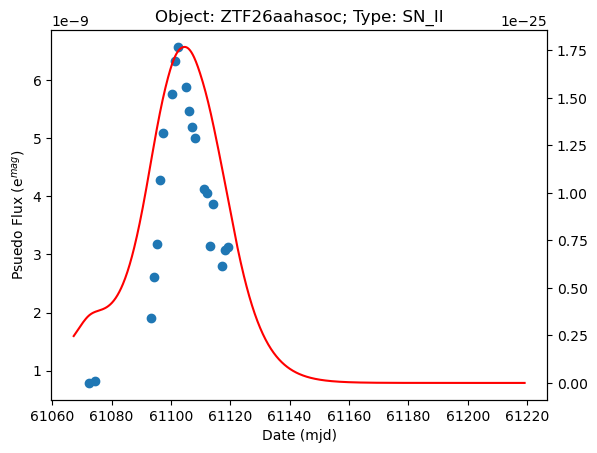

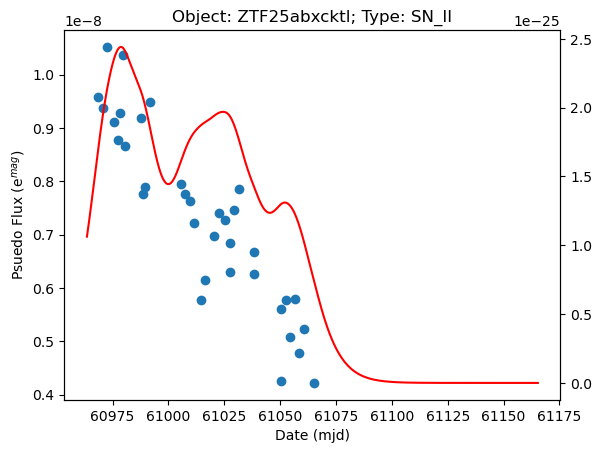

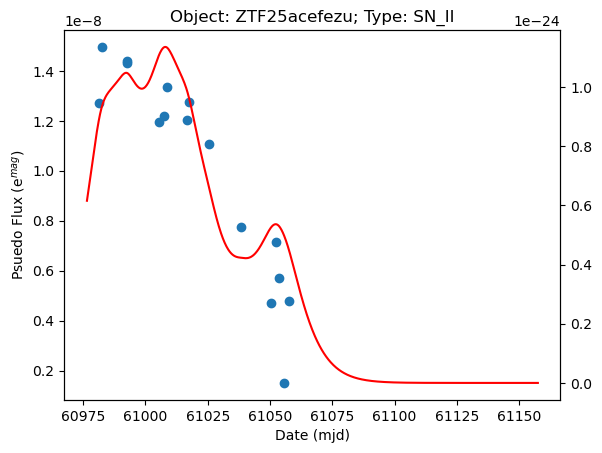

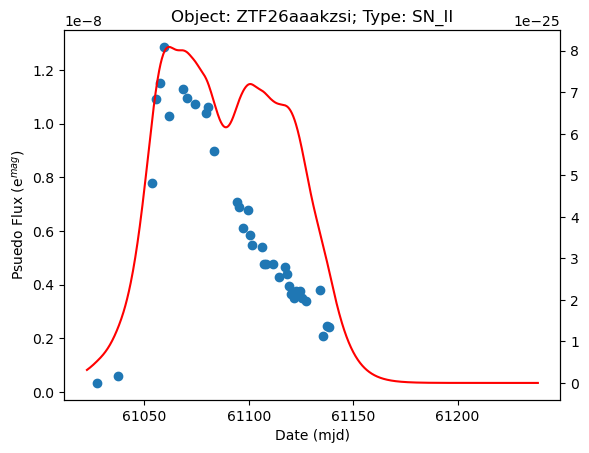

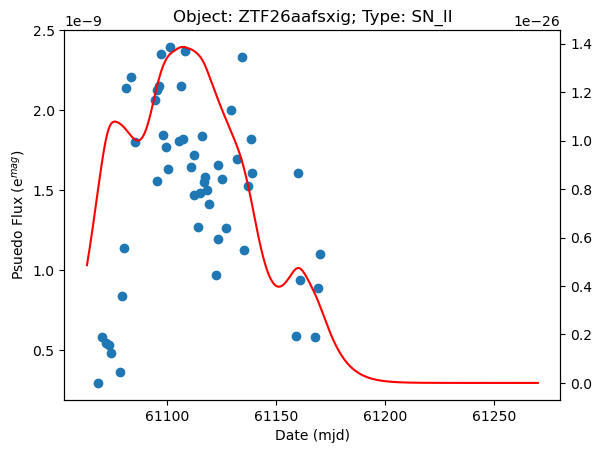

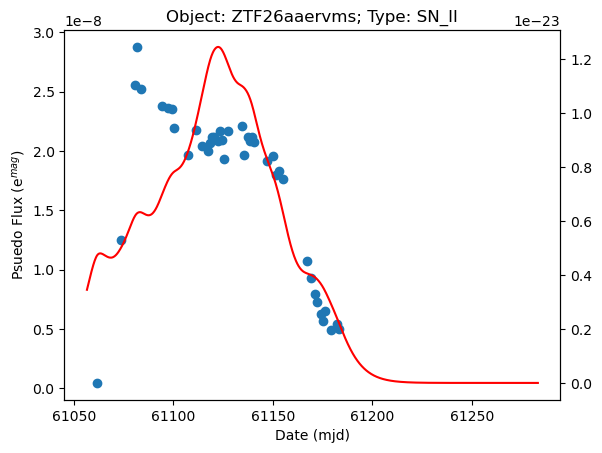

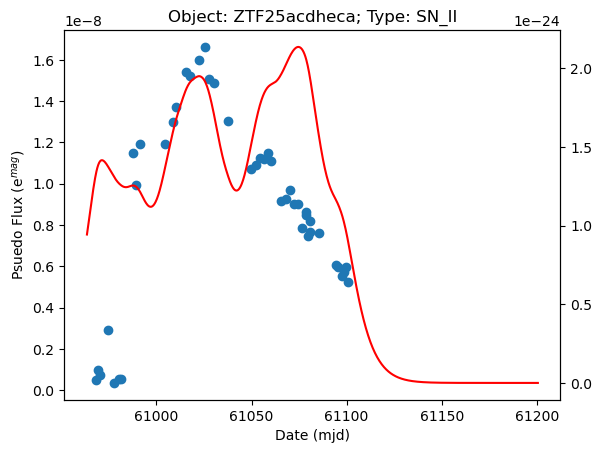

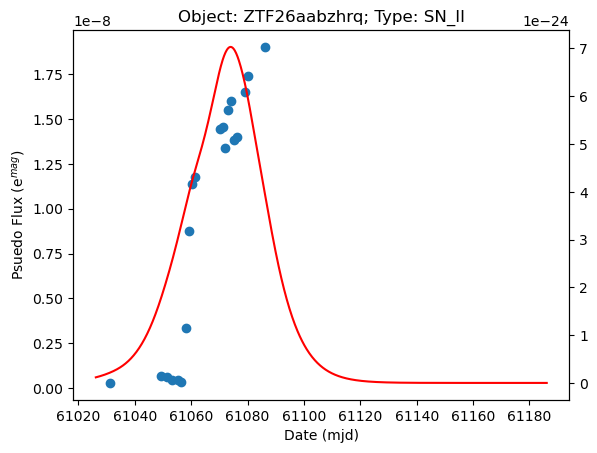

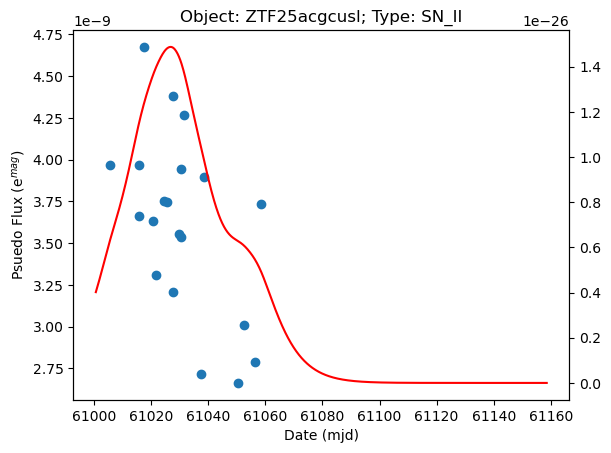

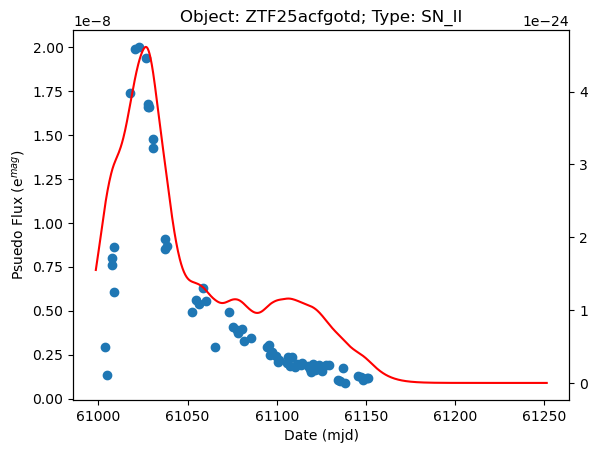

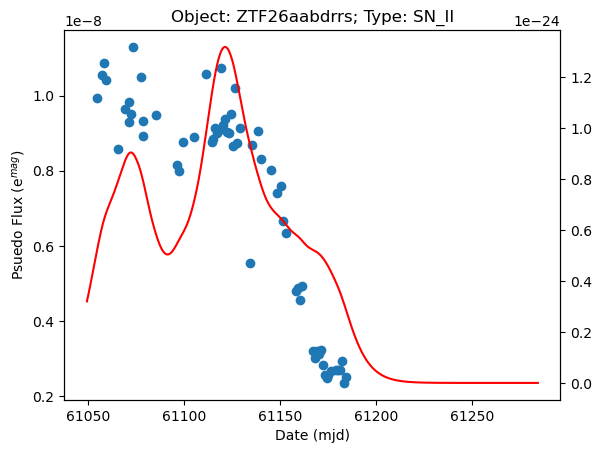

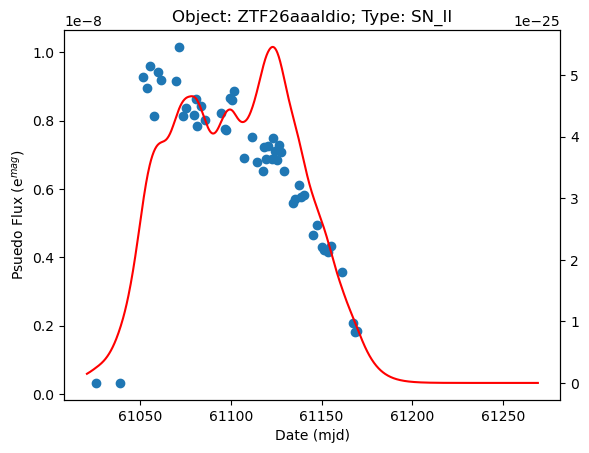

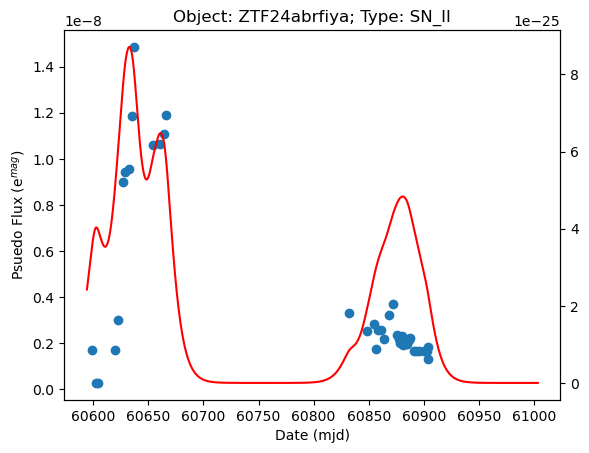

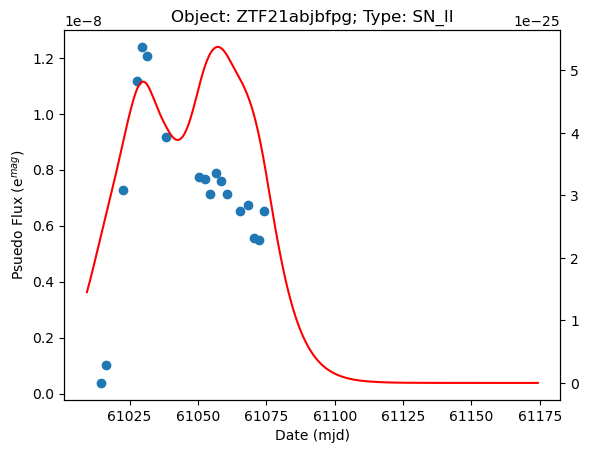

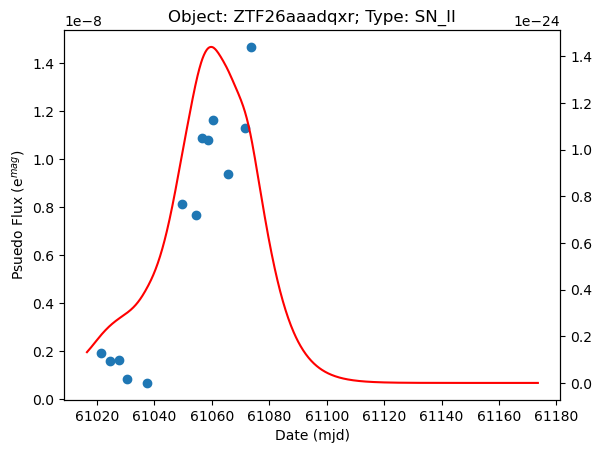

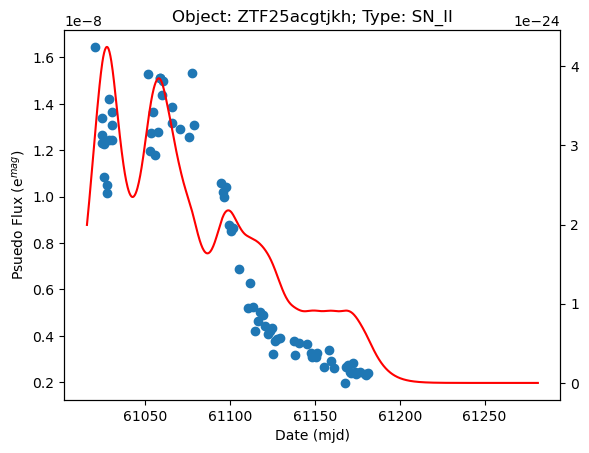

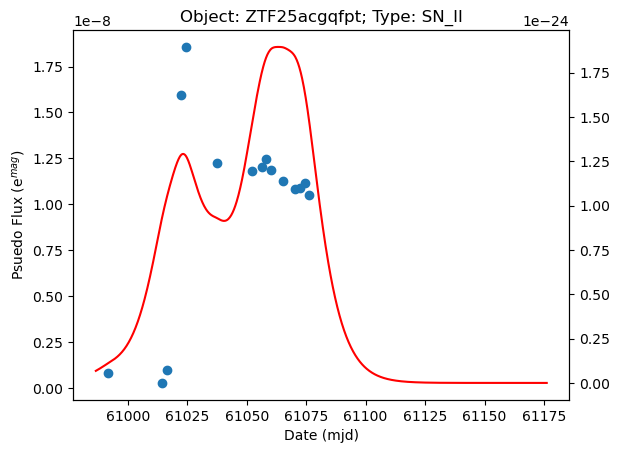

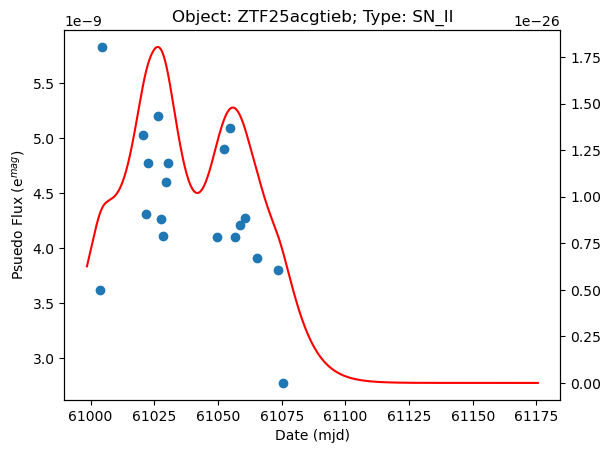

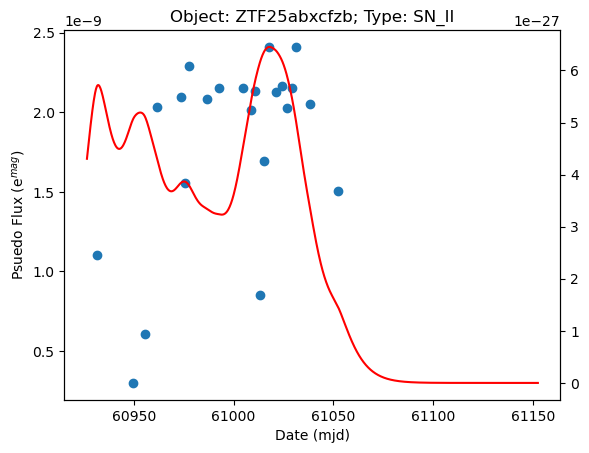

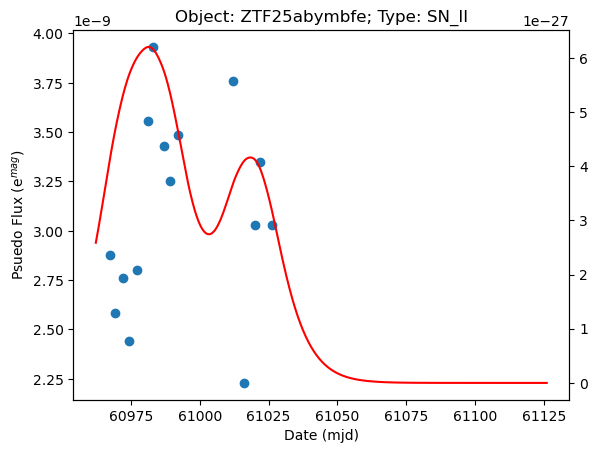

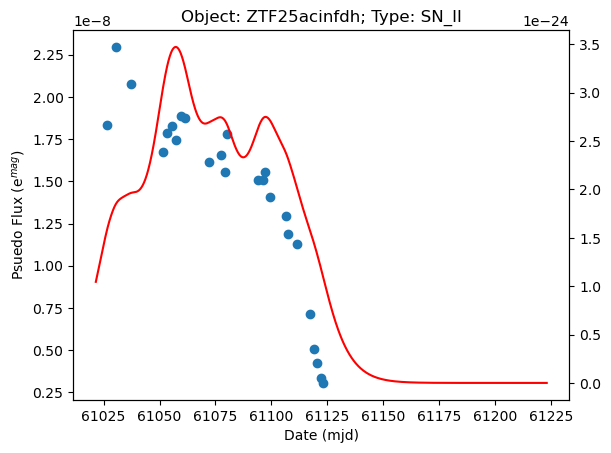

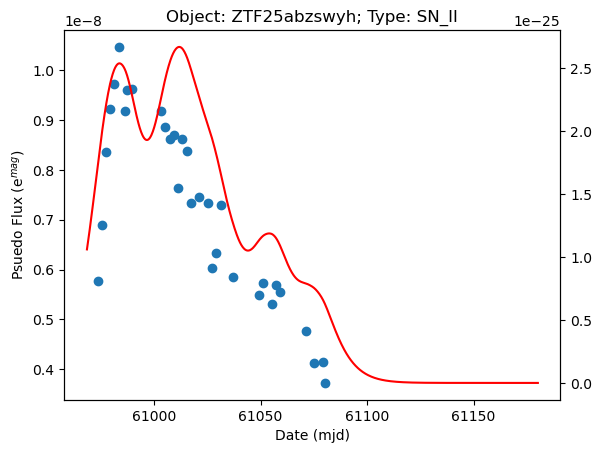

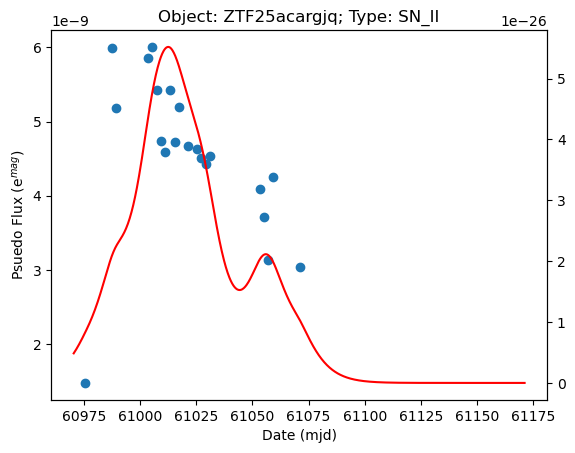

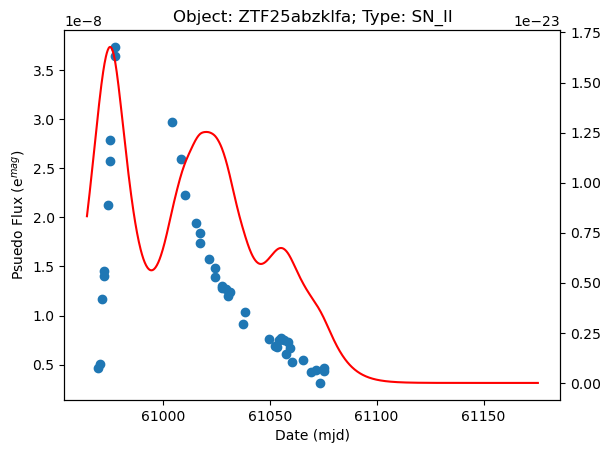

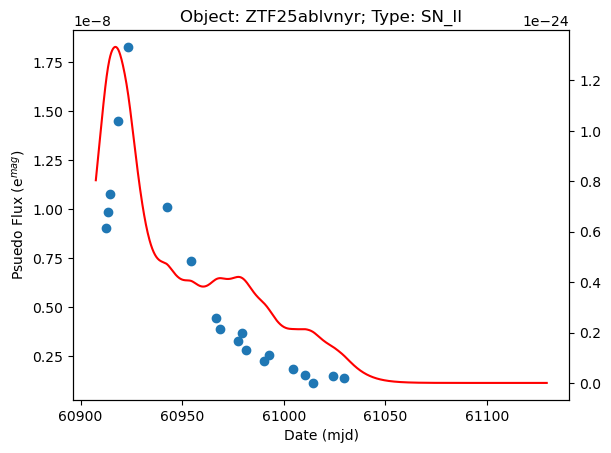

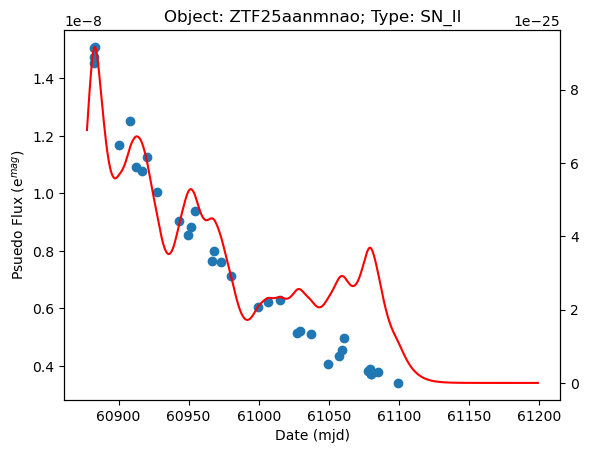

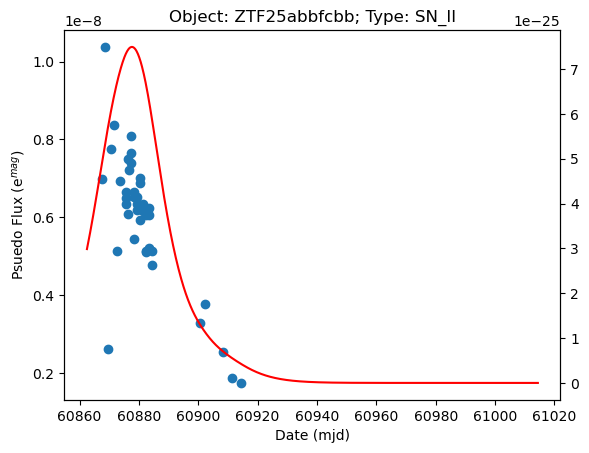

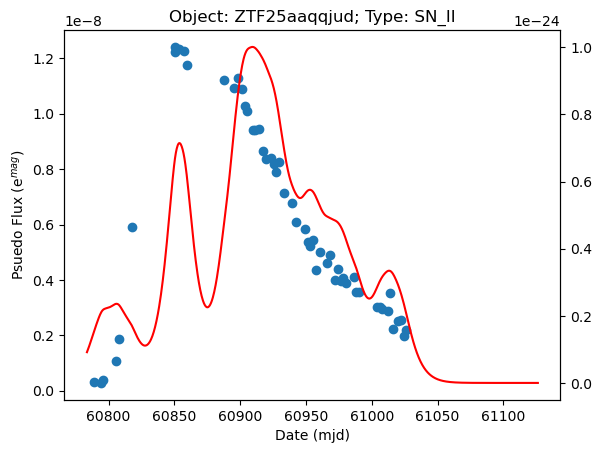

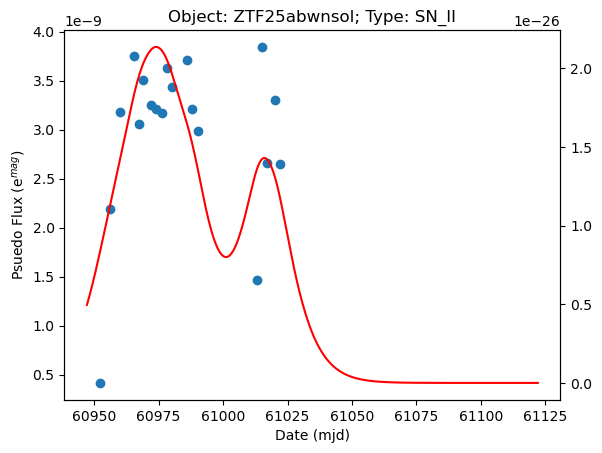

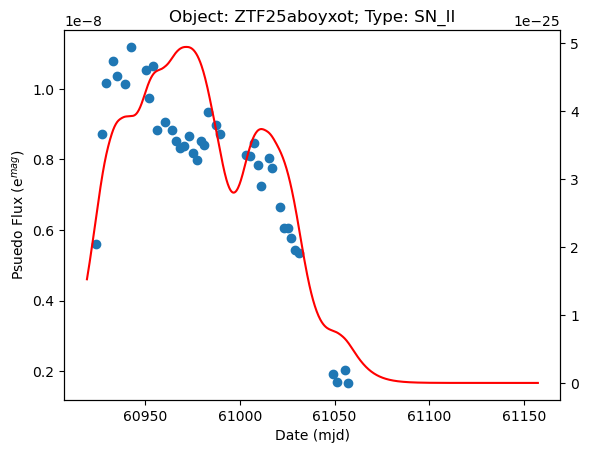

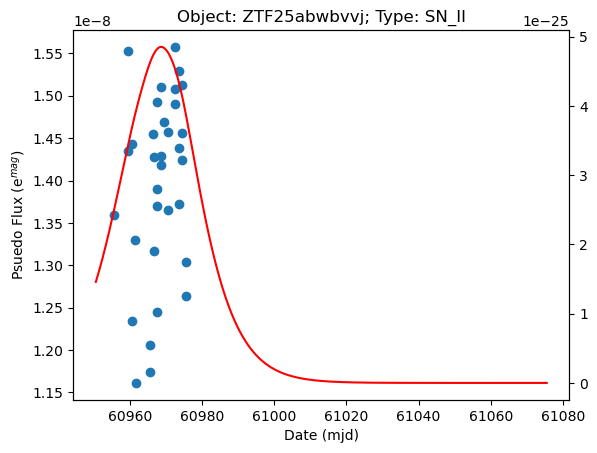

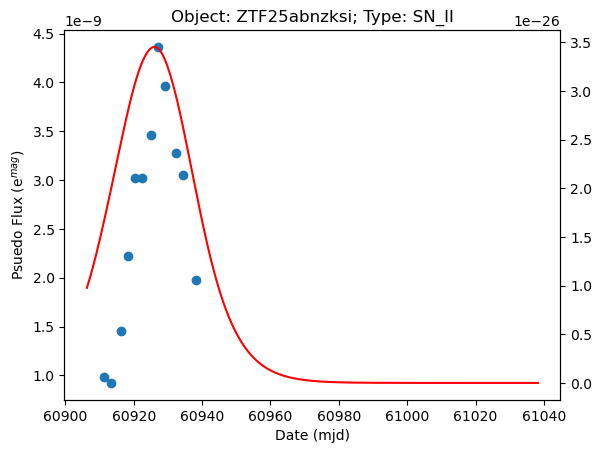

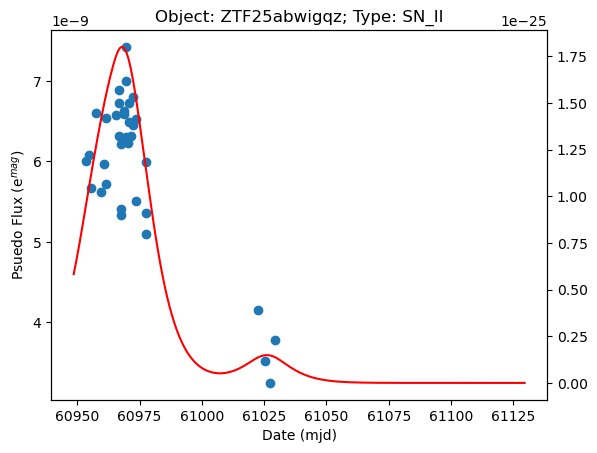

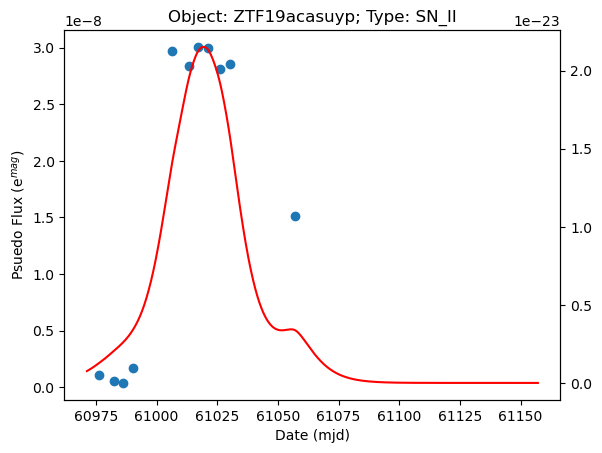

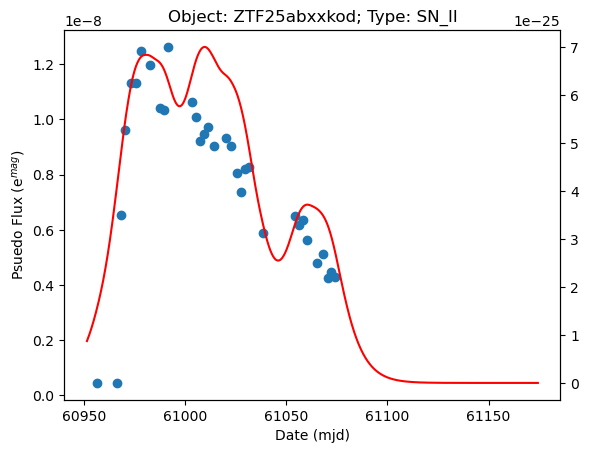

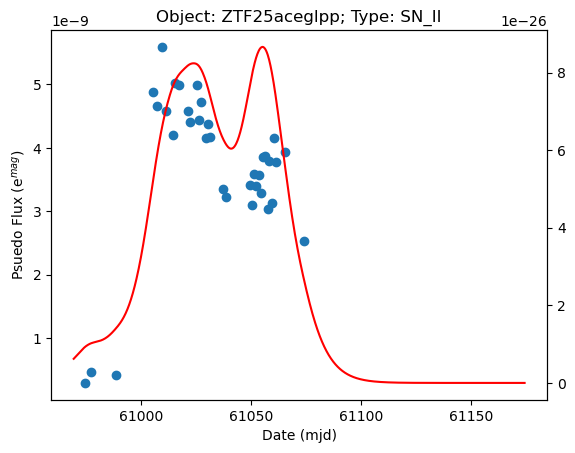

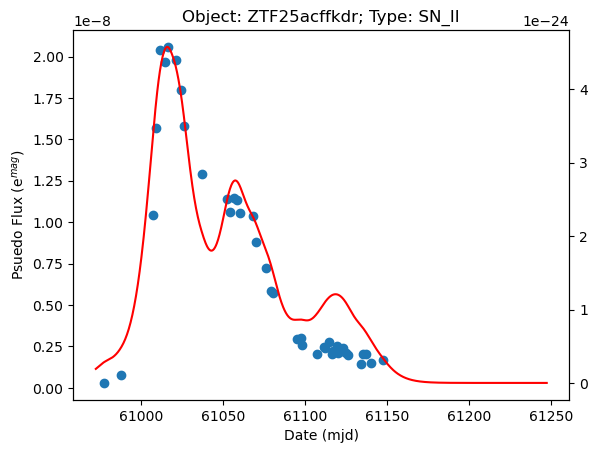

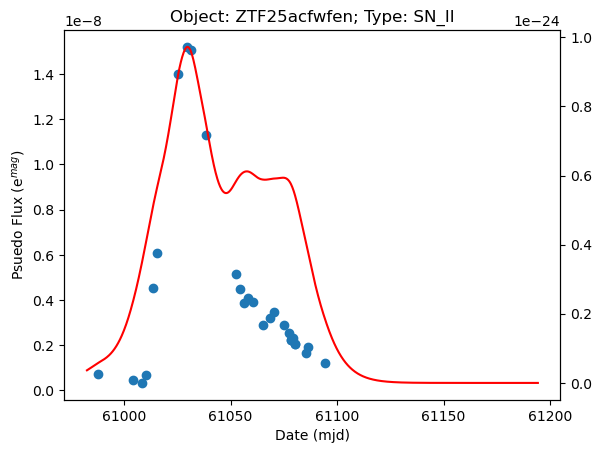

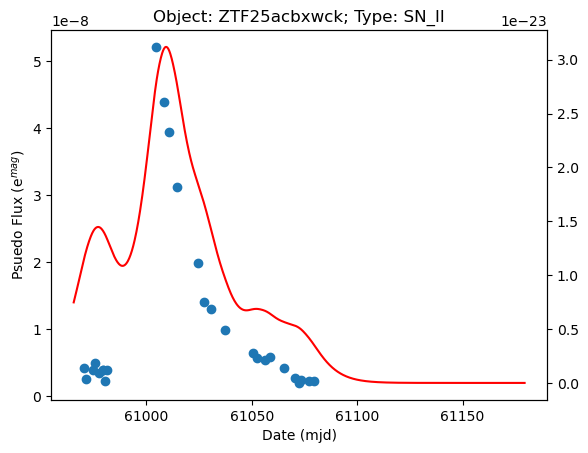

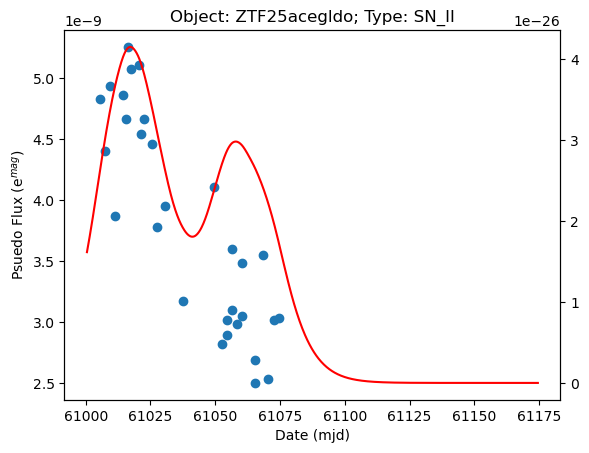

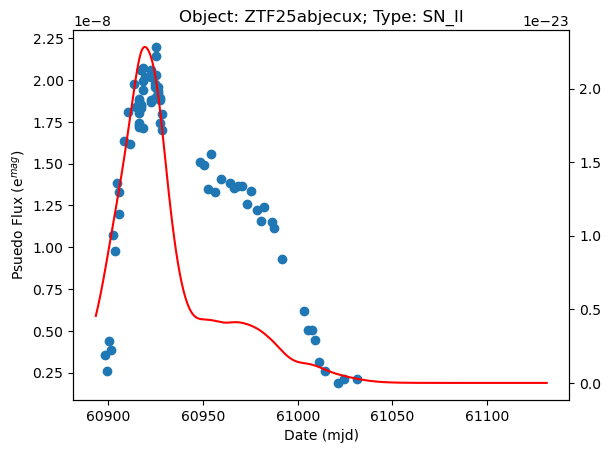

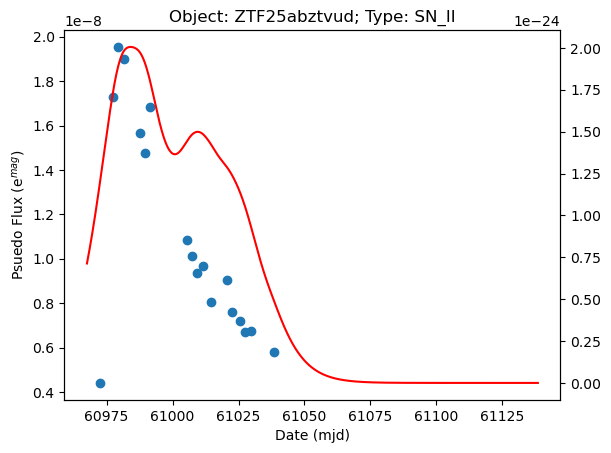

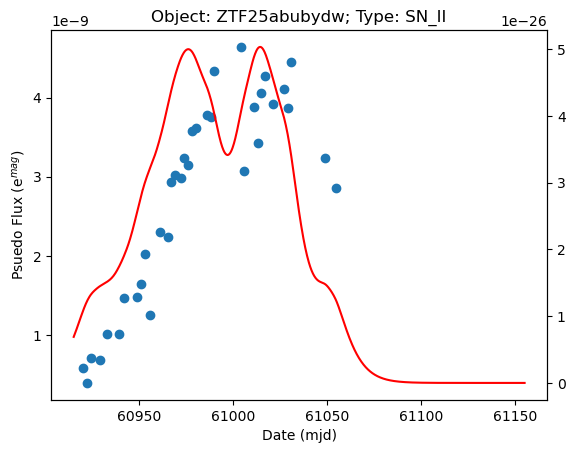

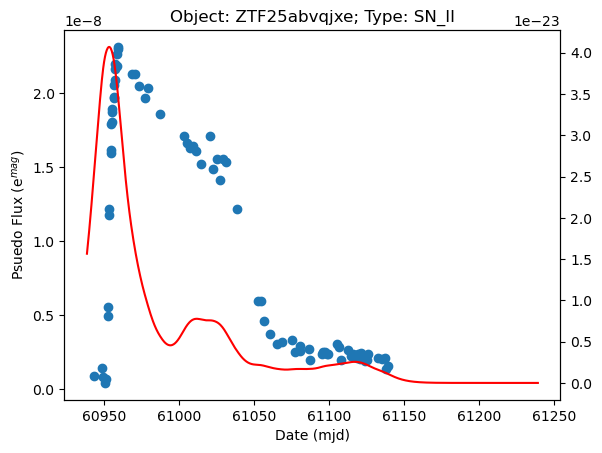

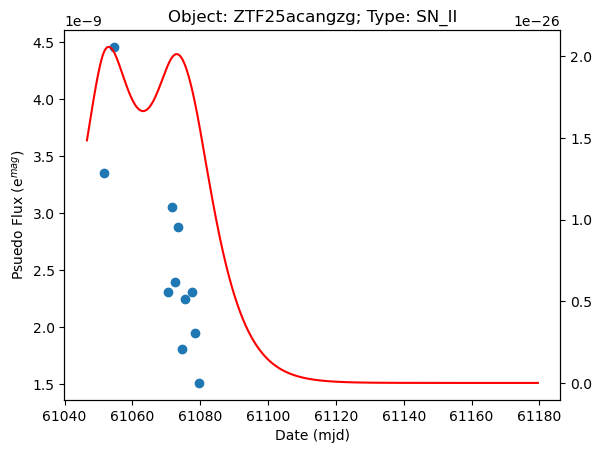

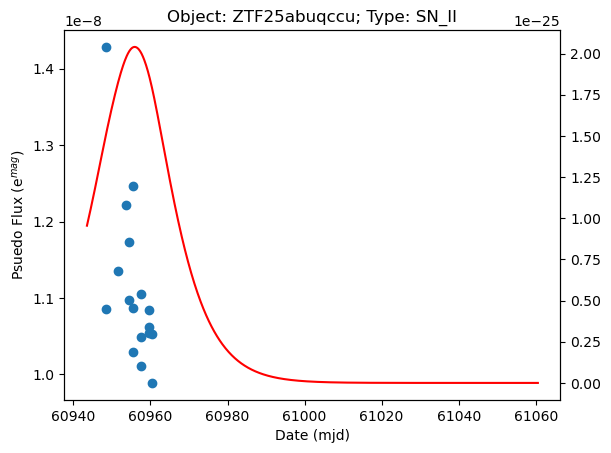

In [17]:
max_curves = 100
dic_curves = []
for light in light_curves[:max_curves]:

    if len(light) > 10:

        #fetch time, psuedo flux, and psuedo flux error
        time, mag_flipped, error = utils.decompose_curve(light)

        if len(mag_flipped) > 10:
            
            #fit line to curve
            pred, pred_var, x_fit = utils.fit_curve(time, mag_flipped, error, mode="george")

            #find peak
            peak = np.max(pred)

            #find rise time
            rise_time = utils.get_rise_time(pred, x_fit, peak, mode="slope")
            #print(rise_time)

            #find fall time
            fall_time = utils.get_fall_time(pred, x_fit, peak, mode="slope")

            if rise_time < 0 or fall_time < 0:
                rise_time = utils.get_rise_time(pred, x_fit, peak, mode="basic")
                fall_time = utils.get_fall_time(pred, x_fit, peak, mode="basic")

            #add curve to dictionary and append to list
            error = np.pow(pred_var, 0.5)    
            dic = {"object": light[0]["oid"], "type": f"SN{curve_type}", "mjd": x_fit, "mag": pred, 
                   "error": error, "peak": peak, "rise": rise_time, "fall": fall_time}
            dic_curves.append(dic)

            #plot fit
            # plt.plot(x_fit, pred)
            # plt.title(light[0]["oid"])
            # plt.show()
            # if peak > 2.2 * 10**-18:
            utils.plot_curve_fit(time, mag_flipped, x_fit, pred, light[0]["oid"], curve_type, round(peak, 2), round(rise_time, 2), round(fall_time, 2))

# table_curves = vstack(dic_curves)
# if curve_type == "Ia":
#     table_curves1 = table_curves[:len(table_curves)//2]
#     table_curves2 = table_curves[len(table_curves)//2:]
#     table_curves1.write(f"../Data/SN{curve_type}_fits1.ecsv", format='ascii.ecsv', overwrite=True)
#     table_curves2.write(f"../Data/SN{curve_type}_fits2.ecsv", format='ascii.ecsv', overwrite=True)
# else:
#     table_curves.write(f"../Data/SN{curve_type}_fits.ecsv", format='ascii.ecsv', overwrite=True)

In [6]:
Table(dic_curves)["object", "type", "peak", "rise", "fall"]

object,type,peak,rise,fall
str12,str4,float64,float64,float64
ZTF26aatbuhc,SNIb,2.2742031755081494e-24,55.30495528594474,111.44533285717625
ZTF25aakeqyr,SNIb,5.760949938168267e-24,91.30914831643167,139.39092768305272
ZTF26aakdoou,SNIb,1.6364406328085203e-24,31.146987170046486,117.58360228309903
ZTF25acipypu,SNIb,2.1976379592421357e-25,14.831727735720051,140.97947521429887
ZTF25aavgfqk,SNIb,1.4449427156460173e-24,35.86498498498986,103.95241741742939
ZTF25aaxqbfo,SNIb,1.380560360135075e-25,21.428613782562024,107.40124498246587
ZTF25aavjchy,SNIb,2.7195404010710343e-25,14.157190614612773,121.69738855256583
ZTF25aavahfn,SNIb,3.411289622429166e-25,39.65080680653773,109.11425030972168
ZTF25aafkxdu,SNIb,5.9603327659909515e-25,38.63609536257718,105.24011050253466


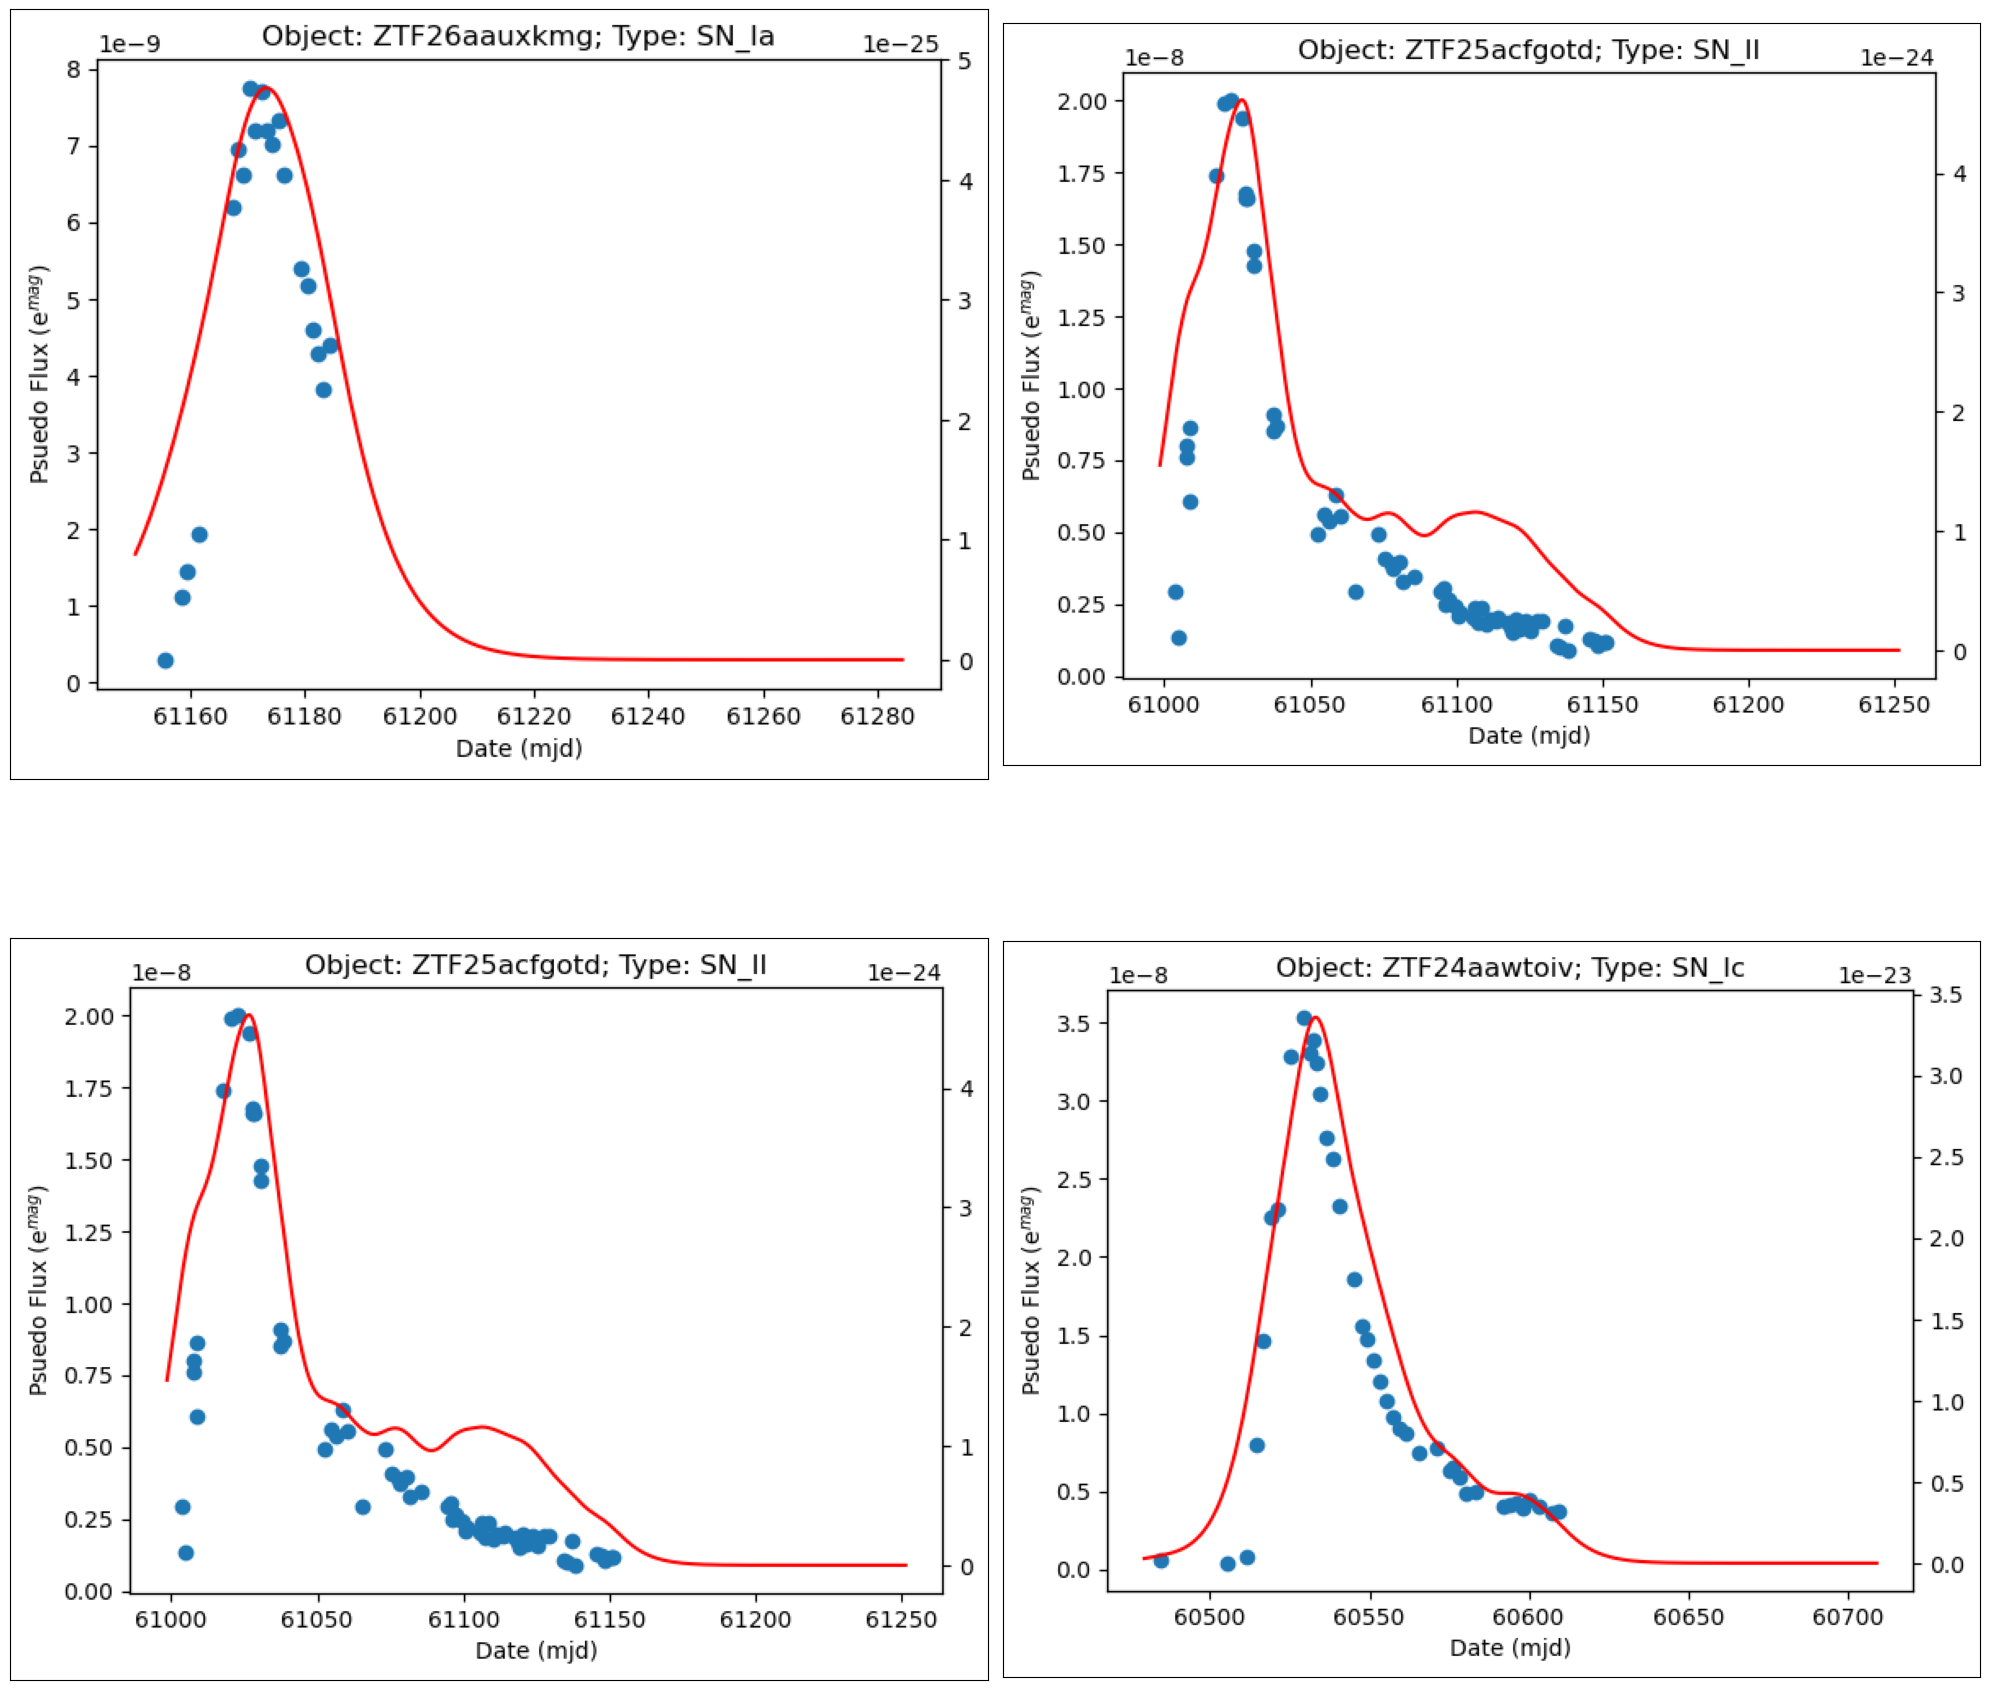

In [29]:
plt.figure(figsize=(20,20))

plt.subplot(221)
sn1aimg = plt.imread("Unknown-1.png")
plt.imshow(sn1aimg)
plt.xticks([])
plt.yticks([])

plt.subplot(222)
sn11img = plt.imread("Unknown-2.png")
plt.imshow(sn11img)
plt.xticks([])
plt.yticks([])

plt.subplot(223)
sn1bimg = plt.imread("Unknown-2.png")
plt.imshow(sn1bimg)
plt.xticks([])
plt.yticks([])

plt.subplot(224)
sn1cimg = plt.imread("Unknown-4.png")
plt.imshow(sn1cimg)
plt.xticks([])
plt.yticks([])

plt.tight_layout()